Project root: c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main
Data directory: c:\4Y 1S\DL assigment\customer-feedback-classification-main\customer-feedback-classification-main\data\processed
Training: (4895, 200) (4895,)
Validation: (1049, 200) (1049,)
Test: (1050, 200) (1050,)
Class weights: {np.int64(0): np.float64(1.8776371308016877), np.int64(1): np.float64(1.317985998922994), np.int64(2): np.float64(0.585246293639407)}


Model: "hotel_review_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,443 (5.03 MB)

 Trainable params: 1,317,443 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.3352 - loss: 1.1019 - val_accuracy: 0.1773 - val_loss: 1.1344
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.3222 - loss: 1.1001 - val_accuracy: 0.1773 - val_loss: 1.1382
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.3244 - loss: 1.1016 - val_accuracy: 0.1773 - val_loss: 1.1169
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.3197 - loss: 1.0997 - val_accuracy: 0.1773 - val_loss: 1.1132
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.3189 - loss: 1.1004 - val_accuracy: 0.1773 - val_loss: 1.1145
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.3197 - loss: 1.0987 - val_accuracy: 0.1773 - val_loss: 1.1339
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.3250 - loss: 1.0998 - val_accuracy: 0.1773 - val_loss: 1.1163
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.3095 - loss: 1.0994 - val_acc

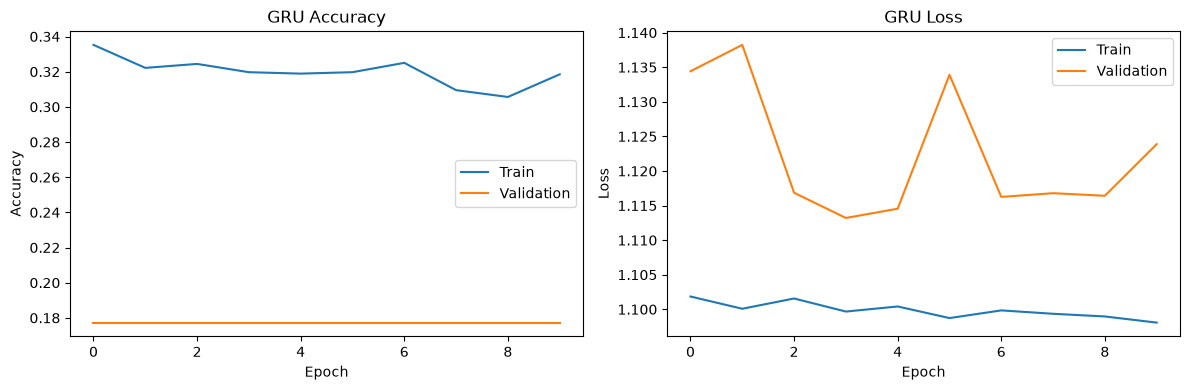

In [1]:
# GRU hotel-review classification
# This notebook uses the shared processed arrays and class weights.
from pathlib import Path
import json
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "processed").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.GRU.gru_model import build_gru_model

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "models_saved" / "gru"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
# Load the common train, validation, and test arrays.
X_train = np.load(DATA_DIR / "X_train_pad.npy")
X_val = np.load(DATA_DIR / "X_val_pad.npy")
X_test = np.load(DATA_DIR / "X_test_pad.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val = np.load(DATA_DIR / "y_val.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

with open(DATA_DIR / "class_weights.pkl", "rb") as file:
    class_weights = pickle.load(file)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Class weights:", class_weights)
model = build_gru_model()
model.summary()
batch_size = 32
epochs = 10

start_time = time.perf_counter()
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    verbose=1,
)
training_seconds = time.perf_counter() - start_time

model.save(OUTPUT_DIR / "gru_model.keras")
with open(OUTPUT_DIR / "gru_history.pkl", "wb") as file:
    pickle.dump(history.history, file)

print(f"Training time: {training_seconds:.2f} seconds")
test_probabilities = model.predict(X_test, batch_size=batch_size, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
class_names = ["Poor", "Average", "Good"]

metrics = {
    "accuracy": float(accuracy_score(y_test, test_predictions)),
    "precision_macro": float(precision_score(y_test, test_predictions, average="macro", zero_division=0)),
    "recall_macro": float(recall_score(y_test, test_predictions, average="macro", zero_division=0)),
    "f1_macro": float(f1_score(y_test, test_predictions, average="macro", zero_division=0)),
    "roc_auc_ovr_macro": float(roc_auc_score(y_test, test_probabilities, multi_class="ovr", average="macro")),
    "training_seconds": float(training_seconds),
    "parameter_count": int(model.count_params()),
}

print(json.dumps(metrics, indent=2))
print(classification_report(y_test, test_predictions, target_names=class_names, zero_division=0))

confusion = confusion_matrix(y_test, test_predictions)
np.save(OUTPUT_DIR / "gru_confusion_matrix.npy", confusion)
with open(OUTPUT_DIR / "gru_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("GRU Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("GRU Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gru_learning_curves.png", dpi=150)
plt.show()